In [2]:
import mne
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy.signal import spectrogram

Using matplotlib as 2D backend.


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\149029967.py:3: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\149029967.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)


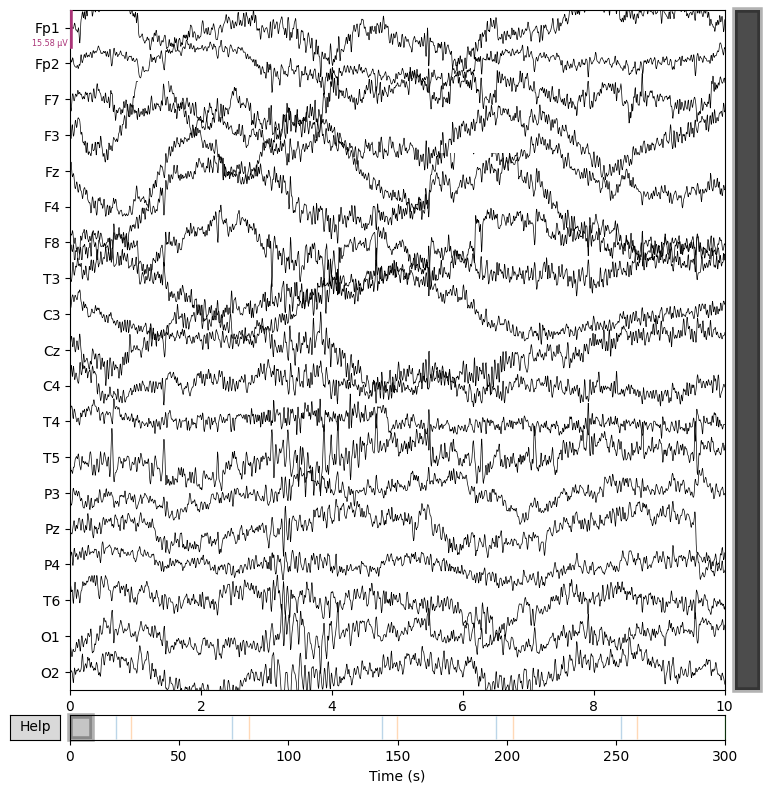

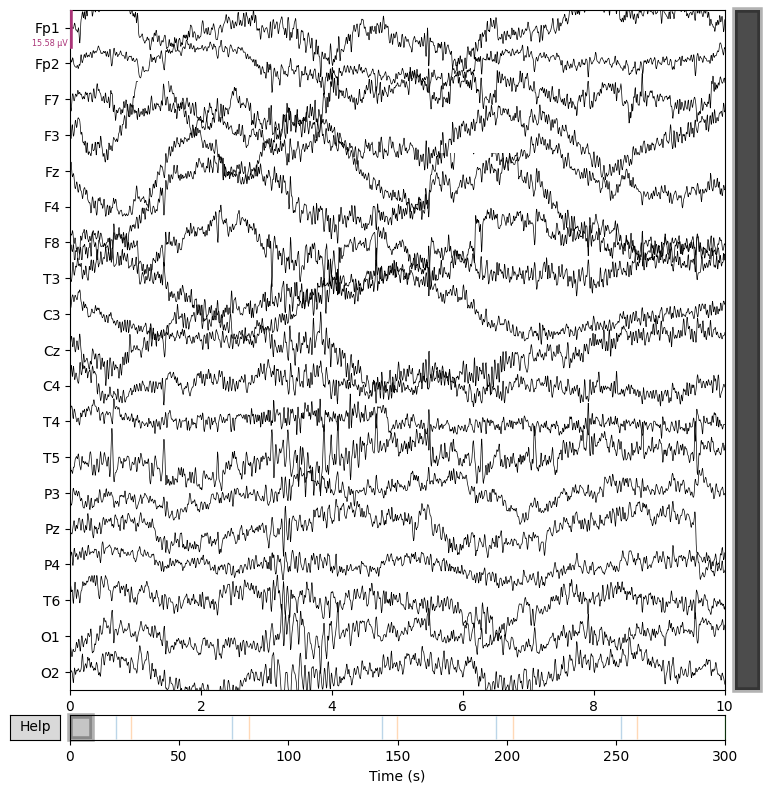

In [3]:
file_path = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\NEW_DATASET_mirovanje\EEG_4002_mirovanje.set"

raw = mne.io.read_raw_eeglab(file_path, preload=True)
raw.plot(n_channels=20, scalings='auto')

In [4]:
INPUT_FOLDER = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\NEW_DATASET_mirovanje"
LABEL_FILE = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset.xlsx"
labels_df = pd.read_excel(LABEL_FILE)

**Spektar snage - 140**

In [5]:
OUTPUT_FOLDER = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_PS"
OUTPUT_EXCEL = os.path.join(OUTPUT_FOLDER, "dataset_PS.csv")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

labels_df["REC_ID"] = labels_df["REC_ID"].astype(str)
label_dict = dict(zip(labels_df["REC_ID"], labels_df["Affective disorder"]))
dataset_rows = []

FMIN = 0.5
FMAX = 45

print("Generiranje PSD slika...\n")

for file in sorted(os.listdir(INPUT_FOLDER)):
    if not file.endswith(".set"):
        continue

    file_path = os.path.join(INPUT_FOLDER, file)
    subject_id = (file.replace(".set", "").replace("EEG_", "").replace("_mirovanje", ""))

    print(f"Obrađujem: {subject_id}")

    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    
    psd = raw.compute_psd(
        fmin=FMIN,
        fmax=FMAX,
        picks="eeg",
        verbose=False
    )

    fig = psd.plot(
        show=False,
        spatial_colors=True,
        average=False
    )

    while len(fig.axes) > 1:
        fig.delaxes(fig.axes[-1])
        
    ax = fig.axes[0]
    ax.set_xlim(FMIN, FMAX)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    fig.tight_layout(pad=0)

    out_path = os.path.join(OUTPUT_FOLDER, f"{subject_id}.png")

    fig.savefig(
        out_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close(fig)

    label = label_dict.get(str(subject_id))
    dataset_rows.append({"REC_ID": subject_id, "file_path": out_path,"Affective disorder": label})

df = pd.DataFrame(dataset_rows)
df.to_csv(OUTPUT_EXCEL, index=False)

print("\nGotovo.")
print(f"Broj slika: {len(df)}")
print(f"CSV spremljen: {OUTPUT_EXCEL}")

Generiranje PSD slika...

Obrađujem: 4002
Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)


Obrađujem: 4007
Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)


Obrađujem: 4009
Plotting power spectral density (dB=True).


...

Obrađujem: GA41709P
Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)


Obrađujem: GA41709Q
Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:23: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\4144107309.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)



Gotovo.
Broj slika: 140
CSV spremljen: C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_PS\dataset_PS.csv


**Spektar snage - 700**

In [11]:
OUTPUT_FOLDER = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_PS_5segments"
OUTPUT_EXCEL = os.path.join(OUTPUT_FOLDER, "dataset_PS_5segments.csv")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

label_dict = dict(zip(labels_df["REC_ID"].astype(str), labels_df["Affective disorder"]))
dataset_rows = []

N_SEGMENTS = 5
FMIN = 0.5
FMAX = 45

print("Generiranje PSD slika iz 5 jednakih segmenata...\n")

for file in sorted(os.listdir(INPUT_FOLDER)):
    if not file.endswith(".set"):
        continue

    file_path = os.path.join(INPUT_FOLDER, file)
    subject_id = file.replace(".set", "").replace("_mirovanje", "").replace("EEG_", "")
    subject_id = str(subject_id)

    print(f"Subjekt: {subject_id}")

    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    total_duration = raw.times[-1]
    segment_length = total_duration / N_SEGMENTS

    print(f"Duljina segmenta: {segment_length:.2f} s")

    for seg_idx in range(N_SEGMENTS):
        t_start = seg_idx * segment_length
        t_end = (seg_idx + 1) * segment_length
        segment = raw.copy().crop(tmin=t_start, tmax=t_end)

        psd = segment.compute_psd(
            fmin=FMIN,
            fmax=FMAX,
            picks="eeg",
            verbose=False
        )

        fig = psd.plot(show=False, spatial_colors=True, average=False)

        for extra_ax in fig.axes[1:]:
            extra_ax.remove()

        ax = fig.axes[0]
        ax.set_xlim(FMIN, FMAX)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

        fig.tight_layout(pad=0)

        out_path = os.path.join(OUTPUT_FOLDER, f"{subject_id}_seg{seg_idx}.png")

        fig.savefig(
            out_path,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0,
            facecolor="white"
        )

        plt.close(fig)

        dataset_rows.append({"REC_ID": subject_id, "segment": seg_idx, "file_path": out_path, "Affective disorder": label_dict.get(subject_id)})

df = pd.DataFrame(dataset_rows)
df.to_csv(OUTPUT_EXCEL, index=False)

print("\nGotovo.")
print(f"Broj slika: {len(df)}")
print(f"CSV spremljen: {OUTPUT_EXCEL}")

Generiranje PSD slika iz 5 jednakih segmenata...

Subjekt: 4002
Duljina segmenta: 60.00 s
Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3419309847.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3419309847.py:24: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3419309847.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)


Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3419309847.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)


Plotting power spectral density (dB=True).


...

Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3419309847.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)


Plotting power spectral density (dB=True).


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3419309847.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0)



Gotovo.
Broj slika: 700
CSV spremljen: C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_PS_5segments\dataset_PS_5segments.csv


**Spektrogram - 140**

In [12]:
OUTPUT_FOLDER = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_spektrogram"
OUTPUT_EXCEL = os.path.join(OUTPUT_FOLDER, "dataset_mirovanje_spektrogram.csv")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

labels_df["REC_ID"] = labels_df["REC_ID"].astype(str).str.strip()
label_dict = dict(zip(labels_df["REC_ID"], labels_df["Affective disorder"]))
dataset_rows = []

FMIN = 0.5
FMAX = 45
NFFT = 256
NOVERLAP = 128

print("Generiranje EEG spektrograma...\n")

for file in sorted(os.listdir(INPUT_FOLDER)):
    if not file.endswith(".set"):
        continue

    try:
        file_path = os.path.join(INPUT_FOLDER, file)

        subject_id = subject_id.strip()
        subject_id = file.replace(".set", "")
        subject_id = subject_id.replace("_mirovanje", "")
        subject_id = subject_id.replace("EEG_", "")

        print(f"Subjekt: {subject_id}")

        raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
        raw.filter(
            l_freq=FMIN,
            h_freq=FMAX,
            picks="eeg",
            verbose=False
        )

        data = raw.get_data(picks="eeg")
        sfreq = raw.info["sfreq"]
        data = (data - np.mean(data, axis=1, keepdims=True)) / (np.std(data, axis=1, keepdims=True) + 1e-10)

        channel_spectrograms = []

        for ch in range(data.shape[0]):
            freqs, times, Sxx = spectrogram(
                data[ch],
                fs=sfreq,
                nperseg=NFFT,
                noverlap=NOVERLAP,
                mode="psd",
                scaling="density"
            )

            freq_mask = (freqs >= FMIN) & (freqs <= FMAX)
            Sxx = Sxx[freq_mask, :]
            channel_spectrograms.append(Sxx)

        Sxx_mean = np.mean(channel_spectrograms, axis=0)
        Sxx_log = 10 * np.log10(Sxx_mean + 1e-10)
        Sxx_log -= np.max(Sxx_log)
        freqs = freqs[freq_mask]

        fig = plt.figure(figsize=(7, 5))
        ax = plt.axes()

        ax.imshow(
            Sxx_log,
            aspect="auto",
            origin="lower",
            extent=[times[0], times[-1], freqs[0], freqs[-1]],
            cmap="viridis",
            vmin=-60,
            vmax=0
            )

        ax.axis("off")
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        out_path = os.path.join(OUTPUT_FOLDER, f"{subject_id}.png")

        fig.savefig(
            out_path,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0,
            transparent=True
        )
        plt.close(fig)
    
        label = label_dict.get(subject_id)
        if label is None:
            print(f"Label nije pronađen za: {subject_id}")

        dataset_rows.append({"REC_ID": subject_id, "file_path": out_path, "Affective disorder": label})

    except Exception as e:
        print(f"GREŠKA kod {file}: {e}")

df = pd.DataFrame(dataset_rows)
df.to_csv(OUTPUT_EXCEL,index=False)

print("\n Gotovo.")
print(f"Broj slika: {len(df)}")
print(f"CSV dataset spremljen: {OUTPUT_EXCEL}")

Generiranje EEG spektrograma...

Subjekt: 4002


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Subjekt: 4007


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Subjekt: 4009


...

Subjekt: GA41709P


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Subjekt: GA41709Q


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\1001854964.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)



 Gotovo.
Broj slika: 140
CSV dataset spremljen: C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_spektrogram\dataset_mirovanje_spektrogram.csv


**Spektrogram - 700**

In [13]:
OUTPUT_FOLDER = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_spektrogram_5seg"
OUTPUT_EXCEL = os.path.join(OUTPUT_FOLDER, "dataset_spektrogram_5seg.csv")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

labels_df["REC_ID"] = labels_df["REC_ID"].astype(str).str.strip()
label_dict = dict(zip(labels_df["REC_ID"],labels_df["Affective disorder"]))
dataset_rows = []

FMIN = 0.5
FMAX = 45
NFFT = 256
NOVERLAP = 128
N_SEGMENTS = 5

print("Generiranje EEG spektrograma (5 segmenata)...\n")

for file in sorted(os.listdir(INPUT_FOLDER)):
    if not file.endswith(".set"):
        continue

    file_path = os.path.join(INPUT_FOLDER, file)
    subject_id = file.replace(".set", "").replace("_mirovanje", "").replace("EEG_", "").strip()
    print(f"Subjekt: {subject_id}")

    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    raw.filter(l_freq=FMIN, h_freq=FMAX, picks="eeg", verbose=False)

    data = raw.get_data(picks="eeg")
    sfreq = raw.info["sfreq"]
    data = (data - np.mean(data, axis=1, keepdims=True)) / (np.std(data, axis=1, keepdims=True) + 1e-10)
    n_samples = data.shape[1]
    seg_len = n_samples // N_SEGMENTS

    label = label_dict.get(subject_id)
    if label is None:
        print(f"Label nije pronađen za {subject_id}")

    for seg_idx in range(N_SEGMENTS):
        segment = data[:, seg_idx * seg_len:(seg_idx + 1) * seg_len]

        channel_spectrograms = []

        for ch in range(segment.shape[0]):
            freqs, times, Sxx = spectrogram(
                segment[ch],
                fs=sfreq,
                nperseg=NFFT,
                noverlap=NOVERLAP,
                mode="psd",
                scaling="density"
            )

            mask = (freqs >= FMIN) & (freqs <= FMAX)
            channel_spectrograms.append(Sxx[mask, :])

        Sxx_mean = np.mean(channel_spectrograms, axis=0)
        Sxx_log = 10 * np.log10(Sxx_mean + 1e-10)
        Sxx_log -= np.max(Sxx_log)

        plt.figure(figsize=(7, 5))
        plt.imshow(
            Sxx_log,
            aspect="auto",
            origin="lower",
            cmap="viridis",
            vmin=-60,
            vmax=0
        )
        plt.axis("off")

        out_path = os.path.join(OUTPUT_FOLDER, f"{subject_id}_seg{seg_idx}.png")

        plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0)
        plt.close()

        dataset_rows.append({"REC_ID": subject_id, "segment": seg_idx, "file_path": out_path, "Affective disorder": label})

df = pd.DataFrame(dataset_rows)
df.to_csv(OUTPUT_EXCEL, index=False)

print("\nGotovo.")
print(f"Broj slika: {len(df)}")
print(f"Dataset spremljen: {OUTPUT_EXCEL}")

Generiranje EEG spektrograma (5 segmenata)...

Subjekt: 4002


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Subjekt: 4007


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Subjekt: 4009


...

Subjekt: GA41709P


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Subjekt: GA41709Q


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\982937474.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)



Gotovo.
Broj slika: 700
Dataset spremljen: C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_spektrogram_5seg\dataset_spektrogram_5seg.csv


**Topomap - 5 x 140**

In [14]:
OUTPUT_FOLDER = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_topomap"
OUTPUT_EXCEL = os.path.join(OUTPUT_FOLDER, "dataset_topomap.csv")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

labels_df["REC_ID"] = labels_df["REC_ID"].astype(str).str.strip()
label_dict = dict(zip(labels_df["REC_ID"], labels_df["Affective disorder"]))
dataset_rows = []

BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

print("Generiranje topomapa...\n")

for file in sorted(os.listdir(INPUT_FOLDER)):
    if not file.endswith(".set"):
        continue

    file_path = os.path.join(INPUT_FOLDER, file)
    subject_id = (file.replace(".set", "").replace("_mirovanje", "").replace("EEG_", "").strip())

    print(f"\nSubjekt: {subject_id}")

    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    raw.rename_channels(lambda x: x.replace("-Ref", "").strip())

    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, on_missing="raise")
    raw.filter(l_freq=0.5, h_freq=45, picks="eeg", verbose=False)

    psd = raw.compute_psd(
        method="welch",
        fmin=0.5,
        fmax=45,
        picks="eeg",
        n_fft=1024,
        n_overlap=512,
        n_per_seg=1024,
        average="median",
        verbose=False
    )
    psd_data = psd.get_data()
    freqs = psd.freqs

    label = label_dict.get(subject_id)
    if label is None:
        print(f"Nema labela za: {subject_id}")

    for band_name, (fmin, fmax) in BANDS.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        band_power = np.mean(psd_data[:, mask], axis=1)
        band_power = 10 * np.log10(band_power + 1e-10)
        median = np.median(band_power)
        mad = np.median(np.abs(band_power - median))
        norm = (band_power - median) / (mad + 1e-10)
        norm = np.clip(norm, -3, 3)

        fig, ax = plt.subplots(figsize=(5, 5))

        mne.viz.plot_topomap(
            norm,
            raw.info,
            axes=ax,
            show=False,
            cmap="jet",
            contours=6
        )
        ax.axis("off")

        out_path = os.path.join(OUTPUT_FOLDER, f"{subject_id}_{band_name}.png")
        plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0)
        plt.close()

        dataset_rows.append({"REC_ID": subject_id, "band": band_name, "file_path": out_path, "Affective disorder": label})

df = pd.DataFrame(dataset_rows)
df.to_csv(OUTPUT_EXCEL, index=False)

print("\nGOTOVO!")
print(f"Broj slika: {len(df)}")
print(f"Excel: {OUTPUT_EXCEL}")

Generiranje topomapa...


Subjekt: 4002


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)



Subjekt: 4007


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)



Subjekt: 4009


...


Subjekt: GA41709P


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)



Subjekt: GA41709Q


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\3121499288.py:28: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)



GOTOVO!
Broj slika: 700
Excel: C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_topomap\dataset_topomap.csv


**Topomap - 5 x 5 x 140**

In [10]:
OUTPUT_FOLDER = r"C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_topomap_5seg"
OUTPUT_EXCEL = os.path.join(OUTPUT_FOLDER, "dataset_topomap_5seg.csv")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

label_dict = dict(zip(labels_df["REC_ID"].astype(str),labels_df["Affective disorder"]))
dataset_rows = []

N_SEGMENTS = 5
FMIN = 0.5
FMAX = 45
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

print("Generiranje topomapa (5 segmenata)...\n")

for file in sorted(os.listdir(INPUT_FOLDER)):
    if not file.endswith(".set"):
        continue

    file_path = os.path.join(INPUT_FOLDER, file)
    subject_id = (file.replace(".set", "").replace("_mirovanje", "").replace("EEG_", ""))

    print(f"Obrađujem: {subject_id}")

    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    raw.rename_channels(lambda x: x.replace("-Ref", "").strip())
    raw.set_eeg_reference("average", projection=False)

    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage,on_missing="raise")

    total_duration = raw.times[-1]
    segment_duration = total_duration / N_SEGMENTS

    for seg_idx in range(N_SEGMENTS):
        tmin = seg_idx * segment_duration
        tmax = (seg_idx + 1) * segment_duration

        segment = raw.copy().crop(tmin=tmin, tmax=tmax)

        psd = segment.compute_psd(
            fmin=FMIN,
            fmax=FMAX,
            picks="eeg",
            verbose=False
        )
        psd_data = psd.get_data()
        freqs = psd.freqs

        for band_name, (fmin, fmax) in BANDS.items():
            freq_mask = ((freqs >= fmin) &(freqs <= fmax))

            total_power = np.sum(psd_data, axis=1)
            band_power = np.sum(psd_data[:, freq_mask], axis=1)
            band_power = (band_power /(total_power + 1e-10))
            band_power = (band_power - np.mean(band_power)) / (np.std(band_power) + 1e-10)

            fig, ax = plt.subplots(figsize=(5, 5))

            im, _ = mne.viz.plot_topomap(
                band_power,
                raw.info,
                axes=ax,
                show=False,
                cmap="jet",
                contours=6
            )

            out_path = os.path.join(OUTPUT_FOLDER, f"{subject_id}_seg{seg_idx+1}_{band_name}.png")

            plt.savefig(
                out_path,
                dpi=300,
                bbox_inches="tight"
            )
            plt.close()

            dataset_rows.append({"REC_ID": subject_id, "segment": seg_idx + 1, "band": band_name, "file_path": out_path, "Affective disorder": label_dict.get(subject_id)})

df = pd.DataFrame(dataset_rows)
df.to_csv(OUTPUT_EXCEL, index=False)

print("\nGotovo!")
print(f"Broj slika: {len(df)}")
print(f"CSV spremljen u:\n{OUTPUT_EXCEL}")

Generiranje topomapa (5 segmenata)...

Obrađujem: 4002
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Obrađujem: 4007
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Obrađujem: 4009
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


...

Obrađujem: GA41709P
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Obrađujem: GA41709Q
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
C:\Users\Lucija\AppData\Local\Temp\ipykernel_27272\629163412.py:30: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)



Gotovo!
Broj slika: 3500
CSV spremljen u:
C:\Users\Lucija\Documents\Lucija\faks\diplomski projekt\datasetovi_final\dataset_mirovanje_topomap_5seg\dataset_topomap_5seg.csv
